# Benchmark: pykarambola vs C++ karambola — AdrenalMNIST3D

Addresses issues [#19](https://github.com/Pitt-IshiharaLab/pykarambola/issues/19) (runtime) and
[#20](https://github.com/Pitt-IshiharaLab/pykarambola/issues/20) (numerical accuracy).

**Dataset:** AdrenalMNIST3D — 1,584 adrenal gland meshes (train 1,188 / val 98 / test 298),
two resolutions (28³ and 64³ voxels), center-of-mass aligned to origin.

**What this notebook does:**
1. Parses pre-computed C++ karambola result folders into CSVs
2. Runs pykarambola on the same `.off` meshes (timed)
3. Reports wall-clock times (issue #19)
4. Plots numerical agreement figures (issue #20)

## Environment

In [8]:
import numpy as np
import pandas as pd
import os
import re
import glob
import time
import platform
import subprocess
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn

import pykarambola

In [9]:
# pykarambola version
print(f"pykarambola version : {pykarambola.__version__}")

# Machine details
print(f"Python              : {platform.python_version()}")
print(f"OS                  : {platform.system()} {platform.release()}")
print(f"Machine             : {platform.machine()}")
try:
    chip = subprocess.run(
        ['sysctl', '-n', 'machdep.cpu.brand_string'],
        capture_output=True, text=True
    ).stdout.strip()
    if not chip:
        chip = platform.processor()
except Exception:
    chip = platform.processor()
print(f"Chip                : {chip}")
print(f"Logical cores       : {os.cpu_count()}")
try:
    phys = subprocess.run(
        ['sysctl', '-n', 'hw.physicalcpu'],
        capture_output=True, text=True
    ).stdout.strip()
    print(f"Physical cores      : {phys}")
except Exception:
    pass

pykarambola version : 0.1.0
Python              : 3.11.14
OS                  : Darwin 24.6.0
Machine             : x86_64
Chip                : Apple M1 Pro
Logical cores       : 10
Physical cores      : 10


## Configuration

In [10]:
CHANNELS   = ['28', '64']
SPLITS     = ['train', 'validation', 'test']
SCALAR_KEYS = ['w000', 'w100', 'w200', 'w300']
VECTOR_KEYS = ['w010', 'w110', 'w210', 'w310']
TENSOR_KEYS = ['w020', 'w120', 'w220', 'w320', 'w102', 'w202']

# Input meshes
BASE_MESH_PATH = '../../dataset/medmnist_benchmarking/adrenal3d'

# C++ karambola result folders and log
BASE_KARA_PATH = '../../dataset/karambola_results/medmnist_benchmarking/adrenal3d'
KARA_LOG       = '../../dataset/karambola_results/medmnist_benchmarking/adrenal3d/run_karambola_adrenal_3d_2026-03-05_16-22-06.log'

# Where to write CSVs and figures
BASE_OUT_PATH  = '../../dataset/karambola_results/medmnist_benchmarking/adrenal3d'
FIGURES_PATH   = 'results'
os.makedirs(FIGURES_PATH, exist_ok=True)

## Helper functions

In [11]:
def calculate_beta(eigenvalues):
    """Anisotropy scalar: min(|λ|) / max(|λ|)."""
    abs_eigs = np.abs(eigenvalues)
    mx = abs_eigs.max()
    return float(abs_eigs.min() / mx) if mx > 1e-12 else float('nan')


def round_floats(df, decimals=5):
    float_cols = df.select_dtypes(include='float').columns
    df[float_cols] = df[float_cols].round(decimals)
    df[float_cols] = df[float_cols].replace(0.0, 1e-5)
    return df


def drop_symmetric_duplicates(df):
    """Drop redundant off-diagonal symmetric columns (e.g. w020_10 when w020_01 == w020_10)."""
    pattern = re.compile(r'^(w\d{3})_(\d)(\d)$')
    seen, to_drop = set(), []
    for col in df.columns:
        m = pattern.match(col)
        if m:
            tensor, i, j = m.groups()
            sym = f'{tensor}_{j}{i}'
            if i != j and sym in df.columns and (col, sym) not in seen and (sym, col) not in seen:
                seen.add((col, sym))
                if (df[col] == df[sym]).all():
                    to_drop.append(sym)
    return df.drop(columns=to_drop)


def parse_filename(fname):
    """Parse '{split}_image_{num}_label_{label}' folder/file names.
    Returns (split, image_num_str, label_int) or None if not matched.
    """
    m = re.match(r'^(\w+?)_image_(\d+)_label_(\d+)$', fname)
    if m:
        return m.group(1), m.group(2), int(m.group(3))
    return None


def parse_karambola_folder(folder_path):
    """Read all karambola output files from a single mesh result folder.
    Returns a dict of raw values or None if files are missing.
    """
    data = {
        'w000': None, 'w100': None, 'w200': None, 'w300': None,
        'w010': [None]*3, 'w110': [None]*3, 'w210': [None]*3, 'w310': [None]*3,
    }
    for t in TENSOR_KEYS:
        data[t] = [[None]*3 for _ in range(3)]
        data[f'{t}_eig'] = [None]*3

    # Scalars
    fp = os.path.join(folder_path, 'w000_w100_w200_w300')
    if os.path.exists(fp):
        with open(fp) as f:
            for line in f:
                if line.startswith('#'): continue
                cols = line.split()
                if len(cols) > 2 and cols[2] in data:
                    data[cols[2]] = float(cols[1])

    # Vectors
    fp = os.path.join(folder_path, 'w010_w110_w210_w310')
    if os.path.exists(fp):
        with open(fp) as f:
            for line in f:
                if line.startswith('#'): continue
                cols = line.split()
                if len(cols) > 4 and cols[4] in data:
                    data[cols[4]] = [float(cols[1]), float(cols[2]), float(cols[3])]

    # Rank-2 tensors
    for t in TENSOR_KEYS:
        fp = os.path.join(folder_path, t)
        if os.path.exists(fp):
            with open(fp) as f:
                for line in f:
                    if line.startswith('#'): continue
                    cols = line.split()
                    if len(cols) > 10 and cols[10] == t:
                        data[t] = [
                            [float(cols[1]), float(cols[2]), float(cols[3])],
                            [float(cols[4]), float(cols[5]), float(cols[6])],
                            [float(cols[7]), float(cols[8]), float(cols[9])],
                        ]

    # Eigensystems
    for t in TENSOR_KEYS:
        fp = os.path.join(folder_path, f'{t}_eigsys')
        if os.path.exists(fp):
            with open(fp) as f:
                for line in f:
                    if line.startswith('#') or 'ALL' not in line: continue
                    parts = line.split()
                    ev = sorted([float(parts[1]), float(parts[5]), float(parts[9])])
                    data[f'{t}_eig'] = ev
    return data


def build_row(data, image_num, label, split):
    """Flatten a parse_karambola_folder result dict into a flat record dict."""
    row = {'image_num': image_num, 'label': label, 'subfolder': split}
    for k in SCALAR_KEYS:
        row[k] = data[k]
    for vk in VECTOR_KEYS:
        for i in range(3):
            row[f'{vk}_{i}'] = data[vk][i]
    for tk in TENSOR_KEYS:
        for i in range(3):
            for j in range(3):
                row[f'{tk}_{i}{j}'] = data[tk][i][j]
        eigs = np.array(data[f'{tk}_eig'], dtype=float)
        row[f'beta_{tk}'] = calculate_beta(eigs)
        for n, ev in enumerate(eigs, 1):
            row[f'{tk}_EVal{n}'] = ev
    return row

## Parse C++ karambola results

In [12]:
kara_times = {}

for channel in CHANNELS:
    kara_path = os.path.join(BASE_KARA_PATH, f'adrenal3d_{channel}')
    out_dir   = os.path.join(BASE_OUT_PATH,  f'adrenal3d_{channel}')
    Path(out_dir).mkdir(parents=True, exist_ok=True)

    t0 = time.perf_counter()
    records = []

    for split in SPLITS:
        split_path = os.path.join(kara_path, split)
        if not os.path.isdir(split_path):
            print(f'  [skip] {split_path} not found')
            continue

        folders = [d for d in os.listdir(split_path)
                   if os.path.isdir(os.path.join(split_path, d))]

        n_parsed = 0
        for folder_name in folders:
            parsed = parse_filename(folder_name)
            if parsed is None:
                continue   # skip old-format folders
            _, image_num, label = parsed
            folder_path = os.path.join(split_path, folder_name)
            data = parse_karambola_folder(folder_path)
            records.append(build_row(data, image_num, label, split))
            n_parsed += 1

        print(f'  adrenal3d_{channel} / {split}: {n_parsed} folders parsed')

    elapsed = time.perf_counter() - t0
    kara_times[channel] = elapsed

    df_k = pd.DataFrame(records)
    # df_k = round_floats(df_k)
    df_k = drop_symmetric_duplicates(df_k)

    csv_path = os.path.join(out_dir, 'adrenal3d_karambola.csv')
    df_k.to_csv(csv_path, index=False)
    print(f'  Saved {len(df_k)} rows → {csv_path}')

    results_csv = os.path.join(FIGURES_PATH, f'adrenal3d_{channel}_karambola.csv')
    df_k.to_csv(results_csv, index=False)
    print(f'  Saved {len(df_k)} rows → {results_csv}')

    print(f'  Parse time: {elapsed:.1f} s\n')

  adrenal3d_28 / train: 1188 folders parsed
  adrenal3d_28 / validation: 98 folders parsed
  adrenal3d_28 / test: 298 folders parsed
  Saved 1584 rows → ../../dataset/karambola_results/medmnist_benchmarking/adrenal3d/adrenal3d_28/adrenal3d_karambola.csv
  Saved 1584 rows → results/adrenal3d_28_karambola.csv
  Parse time: 2.1 s

  adrenal3d_64 / train: 1188 folders parsed
  adrenal3d_64 / validation: 98 folders parsed
  adrenal3d_64 / test: 298 folders parsed
  Saved 1584 rows → ../../dataset/karambola_results/medmnist_benchmarking/adrenal3d/adrenal3d_64/adrenal3d_karambola.csv
  Saved 1584 rows → results/adrenal3d_64_karambola.csv
  Parse time: 2.1 s



In [13]:
# Parse C++ karambola wall-clock times from the run log
kara_log_times = {}   # channel -> total seconds (C++ compute time)
kara_split_times = {} # channel -> {split -> seconds}

with open(KARA_LOG) as f:
    current_channel = None
    for line in f:
        line = line.strip()
        # Track current resolution block
        m = re.match(r'^Resolution:\s+adrenal3d_(\d+)', line)
        if m:
            current_channel = m.group(1)
            kara_split_times[current_channel] = {}
            continue
        # Per-split time
        m = re.match(r'^Time for adrenal3d_\d+/(\w+):\s+(\d+)\s+seconds', line)
        if m and current_channel:
            kara_split_times[current_channel][m.group(1)] = int(m.group(2))
            continue
        # Total per resolution
        m = re.match(r'^Total time for adrenal3d_(\d+):\s+(\d+)\s+seconds', line)
        if m:
            kara_log_times[m.group(1)] = int(m.group(2))

print(f"C++ karambola runtimes (from log: {os.path.basename(KARA_LOG)})")
for ch in CHANNELS:
    splits = kara_split_times.get(ch, {})
    total  = kara_log_times.get(ch, 'N/A')
    print(f"  adrenal3d_{ch}: train={splits.get('train','?')}s  "
          f"validation={splits.get('validation','?')}s  "
          f"test={splits.get('test','?')}s  →  total={total}s")

C++ karambola runtimes (from log: run_karambola_adrenal_3d_2026-03-05_16-22-06.log)
  adrenal3d_28: train=69s  validation=6s  test=17s  →  total=92s
  adrenal3d_64: train=165s  validation=14s  test=42s  →  total=221s


## Run pykarambola

In [14]:
pyk_times = {}

for channel in CHANNELS:
    mesh_path = os.path.join(BASE_MESH_PATH, f'adrenal3d_{channel}')
    out_dir   = os.path.join(BASE_OUT_PATH,  f'adrenal3d_{channel}')
    Path(out_dir).mkdir(parents=True, exist_ok=True)

    t0 = time.perf_counter()
    records = []

    for split in SPLITS:
        split_path = os.path.join(mesh_path, split)
        if not os.path.isdir(split_path):
            print(f'  [skip] {split_path} not found')
            continue

        files = glob.glob(os.path.join(split_path, '*.off'))
        print(f'  adrenal3d_{channel} / {split}: {len(files)} meshes')

        for fpath in files:
            fname = os.path.splitext(os.path.basename(fpath))[0]
            parsed = parse_filename(fname)
            if parsed is None:
                print(f'    [skip] unrecognised filename: {fname}')
                continue
            _, image_num, label = parsed

            tri = pykarambola.parse_off_file(fpath)
            nv, nt = tri.n_vertices(), tri.n_triangles()
            verts = np.array([tri.get_pos_of_vertex(i) for i in range(nv)], dtype=np.float64)
            faces = np.array(
                [[tri.ith_vertex_of_triangle(j, i) for i in range(3)] for j in range(nt)],
                dtype=np.int64,
            )
            result = pykarambola.minkowski_tensors(verts, faces)

            row = {'image_num': image_num, 'label': label, 'subfolder': split}
            for k in SCALAR_KEYS:
                row[k] = result[k]
            for vk in VECTOR_KEYS:
                for i in range(3):
                    row[f'{vk}_{i}'] = result[vk][i]
            for tk in TENSOR_KEYS:
                mat = result[tk]
                for i in range(3):
                    for j in range(3):
                        row[f'{tk}_{i}{j}'] = mat[i, j]
                eigvals = result[f'{tk}_eigvals']
                row[f'beta_{tk}'] = calculate_beta(eigvals)
                for n, ev in enumerate(sorted(eigvals), 1):
                    row[f'{tk}_EVal{n}'] = ev
            records.append(row)

    elapsed = time.perf_counter() - t0
    pyk_times[channel] = elapsed

    df_py = pd.DataFrame(records)
    df_py = drop_symmetric_duplicates(df_py)
    # df_py = round_floats(df_py)

    csv_path = os.path.join(out_dir, 'adrenal3d_pykarambola.csv')
    df_py.to_csv(csv_path, index=False)
    print(f'  Saved {len(df_py)} rows → {csv_path}')

    results_csv = os.path.join(FIGURES_PATH, f'adrenal3d_{channel}_pykarambola.csv')
    df_py.to_csv(results_csv, index=False)
    print(f'  Saved {len(df_py)} rows → {results_csv}')

    print(f'  Run time: {elapsed:.1f} s\n')

  adrenal3d_28 / train: 1188 meshes
  adrenal3d_28 / validation: 98 meshes
  adrenal3d_28 / test: 298 meshes
  Saved 1584 rows → ../../dataset/karambola_results/medmnist_benchmarking/adrenal3d/adrenal3d_28/adrenal3d_pykarambola.csv
  Saved 1584 rows → results/adrenal3d_28_pykarambola.csv
  Run time: 22.8 s

  adrenal3d_64 / train: 1188 meshes
  adrenal3d_64 / validation: 98 meshes
  adrenal3d_64 / test: 298 meshes
  Saved 1584 rows → ../../dataset/karambola_results/medmnist_benchmarking/adrenal3d/adrenal3d_64/adrenal3d_pykarambola.csv
  Saved 1584 rows → results/adrenal3d_64_pykarambola.csv
  Run time: 118.0 s



## Runtime comparison (issue #19)

In [15]:
print("Wall-clock times — AdrenalMNIST3D (1,584 meshes per resolution)")
print(f"{'Resolution':<16} {'C++ karambola':>18} {'pykarambola':>16} {'speedup':>10}")
print('-' * 64)

for ch in CHANNELS:
    k_t  = kara_log_times.get(ch, float('nan'))
    py_t = pyk_times.get(ch, float('nan'))
    speedup = k_t / py_t if py_t > 0 else float('nan')
    print(f"adrenal3d_{ch:<6}  {k_t:>14} s  {py_t:>12.1f} s  {speedup:>8.1f}×")

total_k  = sum(kara_log_times.values())
total_py = sum(pyk_times.values())
print('-' * 64)
print(f"{'Total':<16}  {total_k:>14} s  {total_py:>12.1f} s  {total_k/total_py:>8.1f}×")
print()
print(f"Log file: {os.path.basename(KARA_LOG)}")
print()
print("Note: C++ karambola time is total wall-clock time including I/O")
print("      (one output folder per mesh, written sequentially).")
print("      pykarambola time is pure Python compute (no file output).")

Wall-clock times — AdrenalMNIST3D (1,584 meshes per resolution)
Resolution            C++ karambola      pykarambola    speedup
----------------------------------------------------------------
adrenal3d_28                  92 s          22.8 s       4.0×
adrenal3d_64                 221 s         118.0 s       1.9×
----------------------------------------------------------------
Total                        313 s         140.8 s       2.2×

Log file: run_karambola_adrenal_3d_2026-03-05_16-22-06.log

Note: C++ karambola time is total wall-clock time including I/O
      (one output folder per mesh, written sequentially).
      pykarambola time is pure Python compute (no file output).


## Numerical accuracy (issue #20)

Load the CSVs, merge on mesh identity, and compute relative errors.
Figures produced:
1. Scatter plots — pyk vs karambola for scalar functionals (w000, w100, w200, w300)
2. Bar chart — mean relative error per functional
3. Summary table — max and mean relative error per functional
4. Heatmap — mean relative error per mesh × feature

In [16]:
ABS_THRESHOLD = 1e-10   # treat both values as zero when both are below this

merged = {}   # channel -> merged DataFrame

for channel in CHANNELS:
    out_dir = os.path.join(BASE_OUT_PATH, f'adrenal3d_{channel}')
    df_k  = pd.read_csv(os.path.join(out_dir, 'adrenal3d_karambola.csv'))
    df_py = pd.read_csv(os.path.join(out_dir, 'adrenal3d_pykarambola.csv'))

    df_m = df_k.merge(df_py, on=['image_num', 'label', 'subfolder'],
                      suffixes=('_k', '_py'))
    merged[channel] = df_m
    print(f'adrenal3d_{channel}: {len(df_m)} matched rows')

adrenal3d_28: 1584 matched rows
adrenal3d_64: 1584 matched rows


> **Note (current results):** Values are compared without any additional rounding beyond the 5-decimal
> `round_floats` pass applied during CSV generation.
> pykarambola outputs are on the order of **~1e+12**, while C++ karambola measures reach up to **~1e+16**.
> The relative-error metric normalises by the karambola value, so the scale difference does not inflate
> error percentages, but it is worth noting for future normalisation or pre-processing steps.

In [17]:
def relative_error_series(df_m, col):
    """Per-row relative error (%) between _k and _py columns."""
    # k  = df_m[f'{col}_k'].round(5)
    # py = df_m[f'{col}_py'].round(5)
    k  = df_m[f'{col}_k']
    py = df_m[f'{col}_py']
    both_tiny = (k.abs() < ABS_THRESHOLD) & (py.abs() < ABS_THRESHOLD)
    denom = k.abs().where(~both_tiny, np.nan).replace(0, np.nan)
    return (k - py).abs() / denom * 100


def error_summary(df_m, cols):
    """DataFrame with mean and max relative error per column."""
    rows = []
    for col in cols:
        err = relative_error_series(df_m, col)
        rows.append({'feature': col,
                     'mean_rel_err_%': err.mean(),
                     'max_rel_err_%':  err.max()})
    return pd.DataFrame(rows).set_index('feature')

### Figure 1 — Scatter: pykarambola vs C++ karambola (scalar functionals)

Saved → results/scatter_all_features_28.pdf


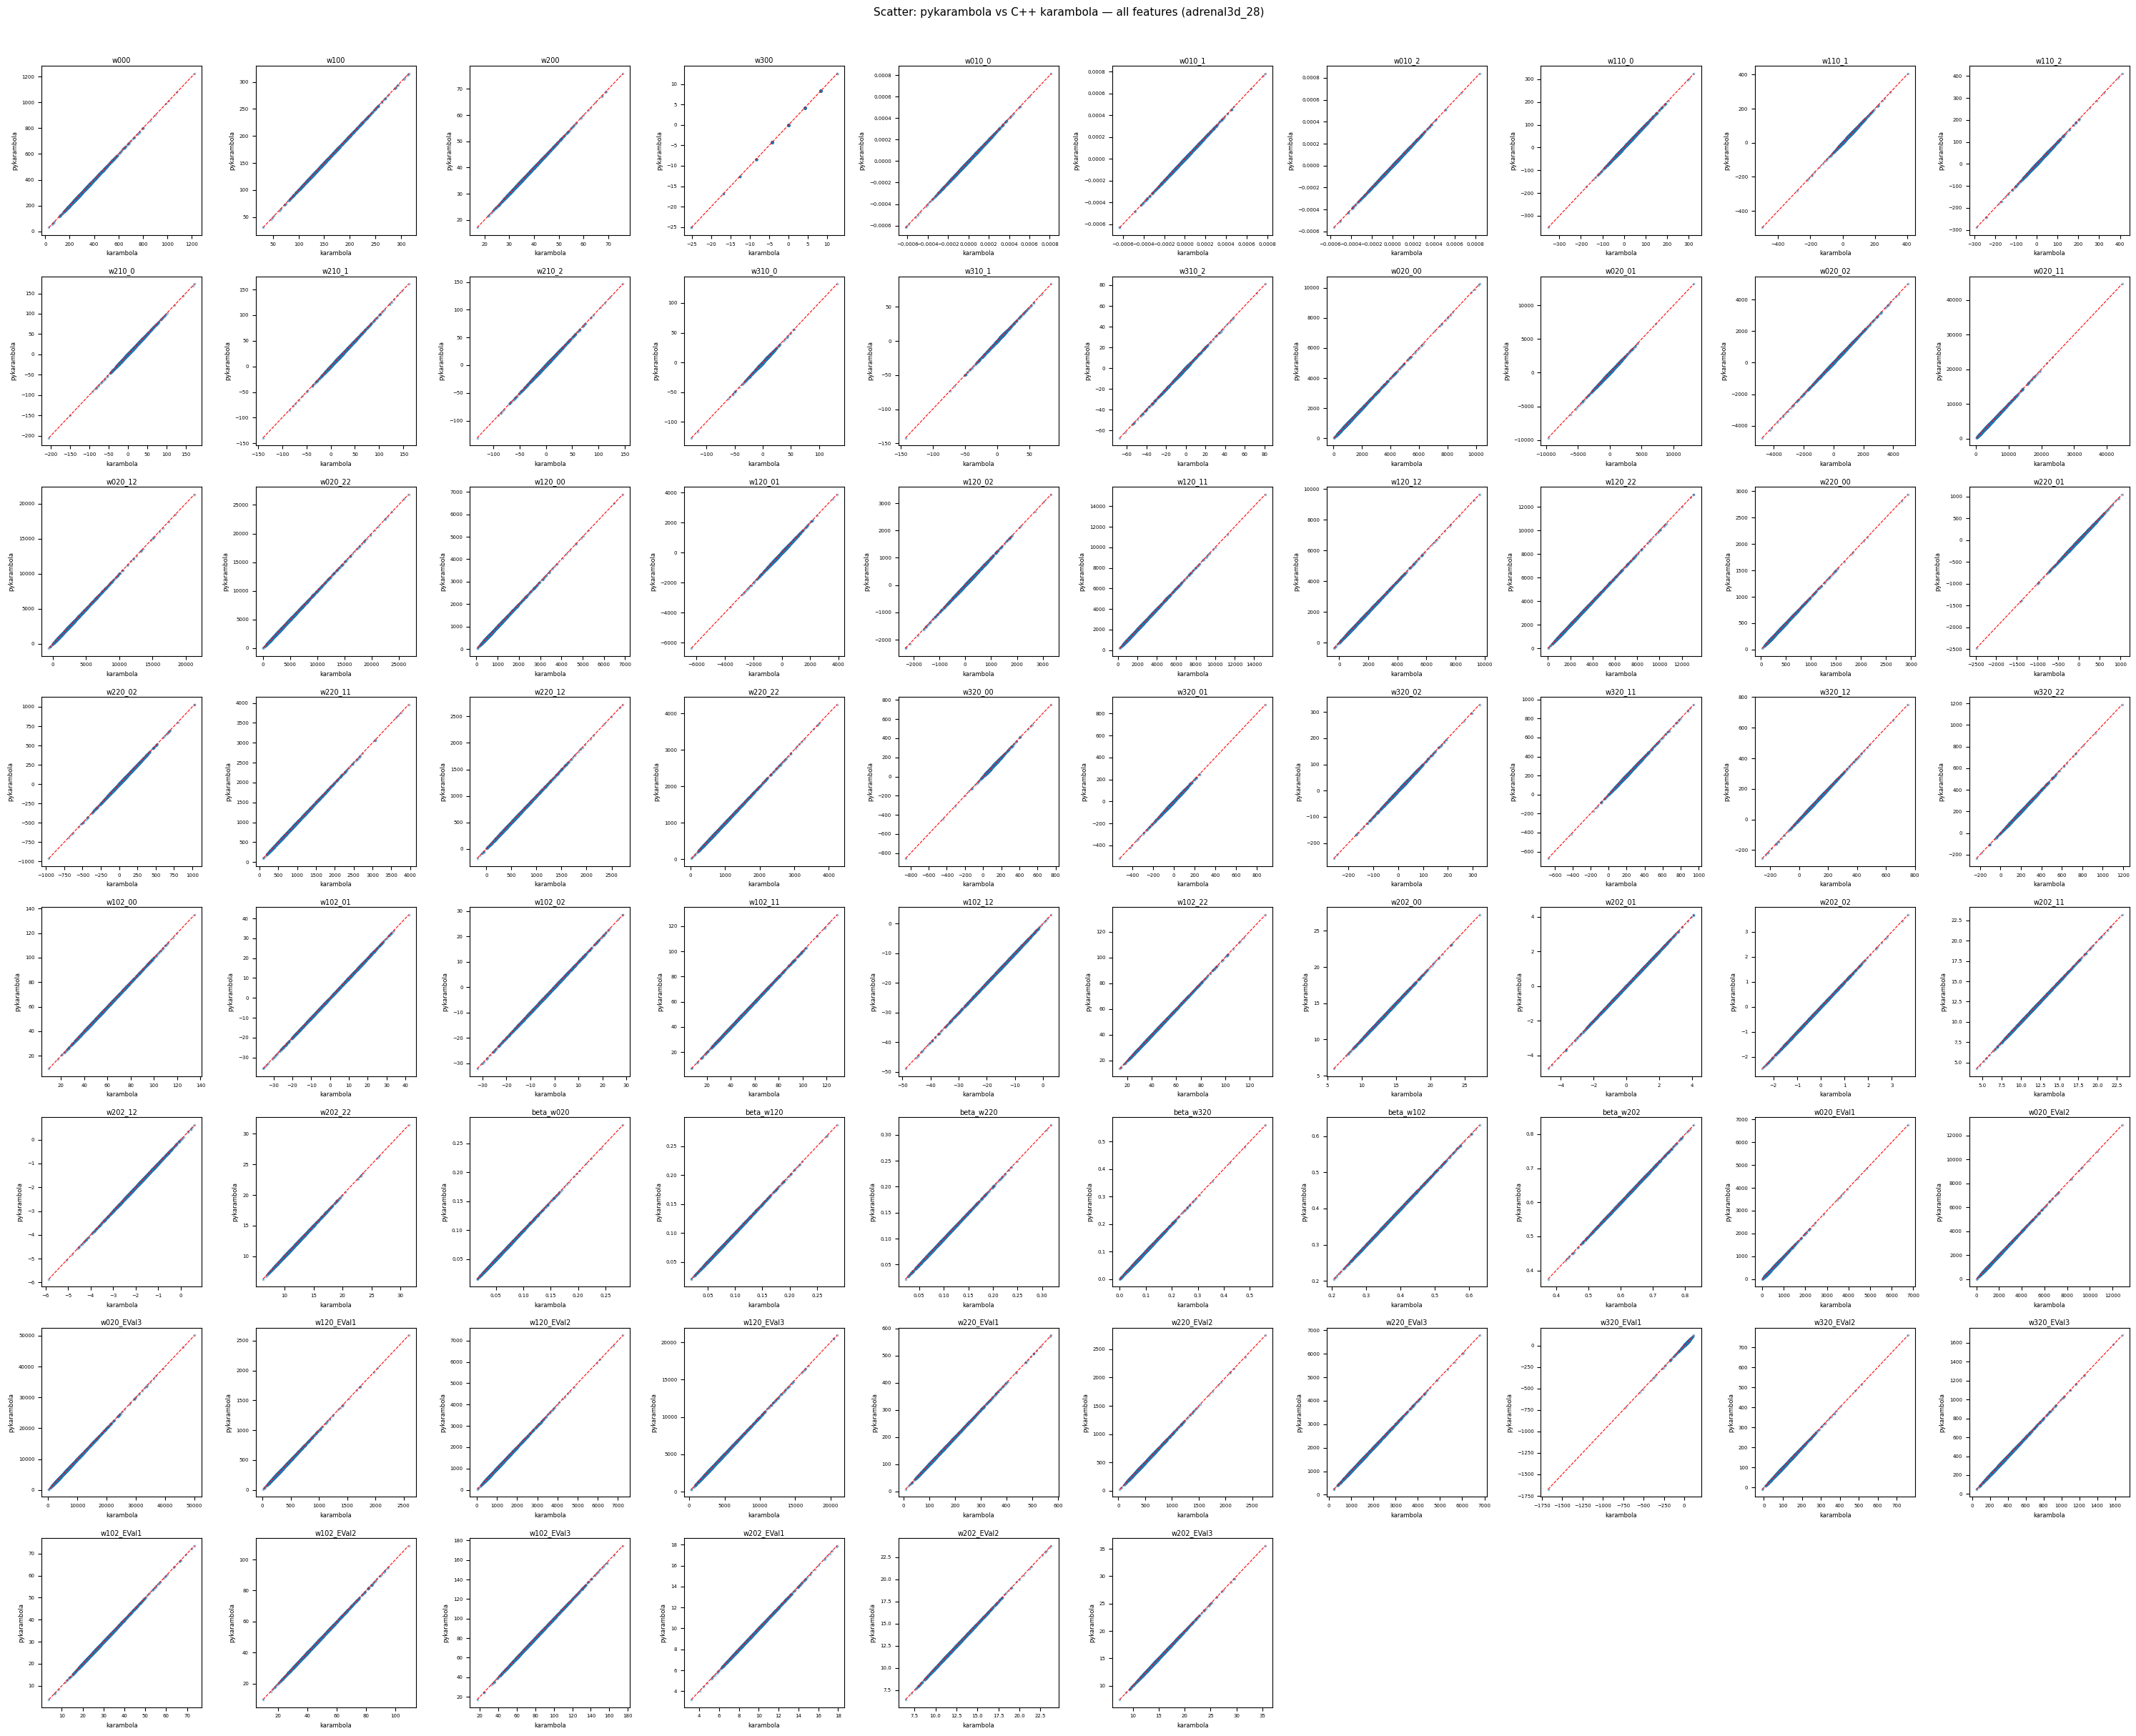

Saved → results/scatter_all_features_64.pdf


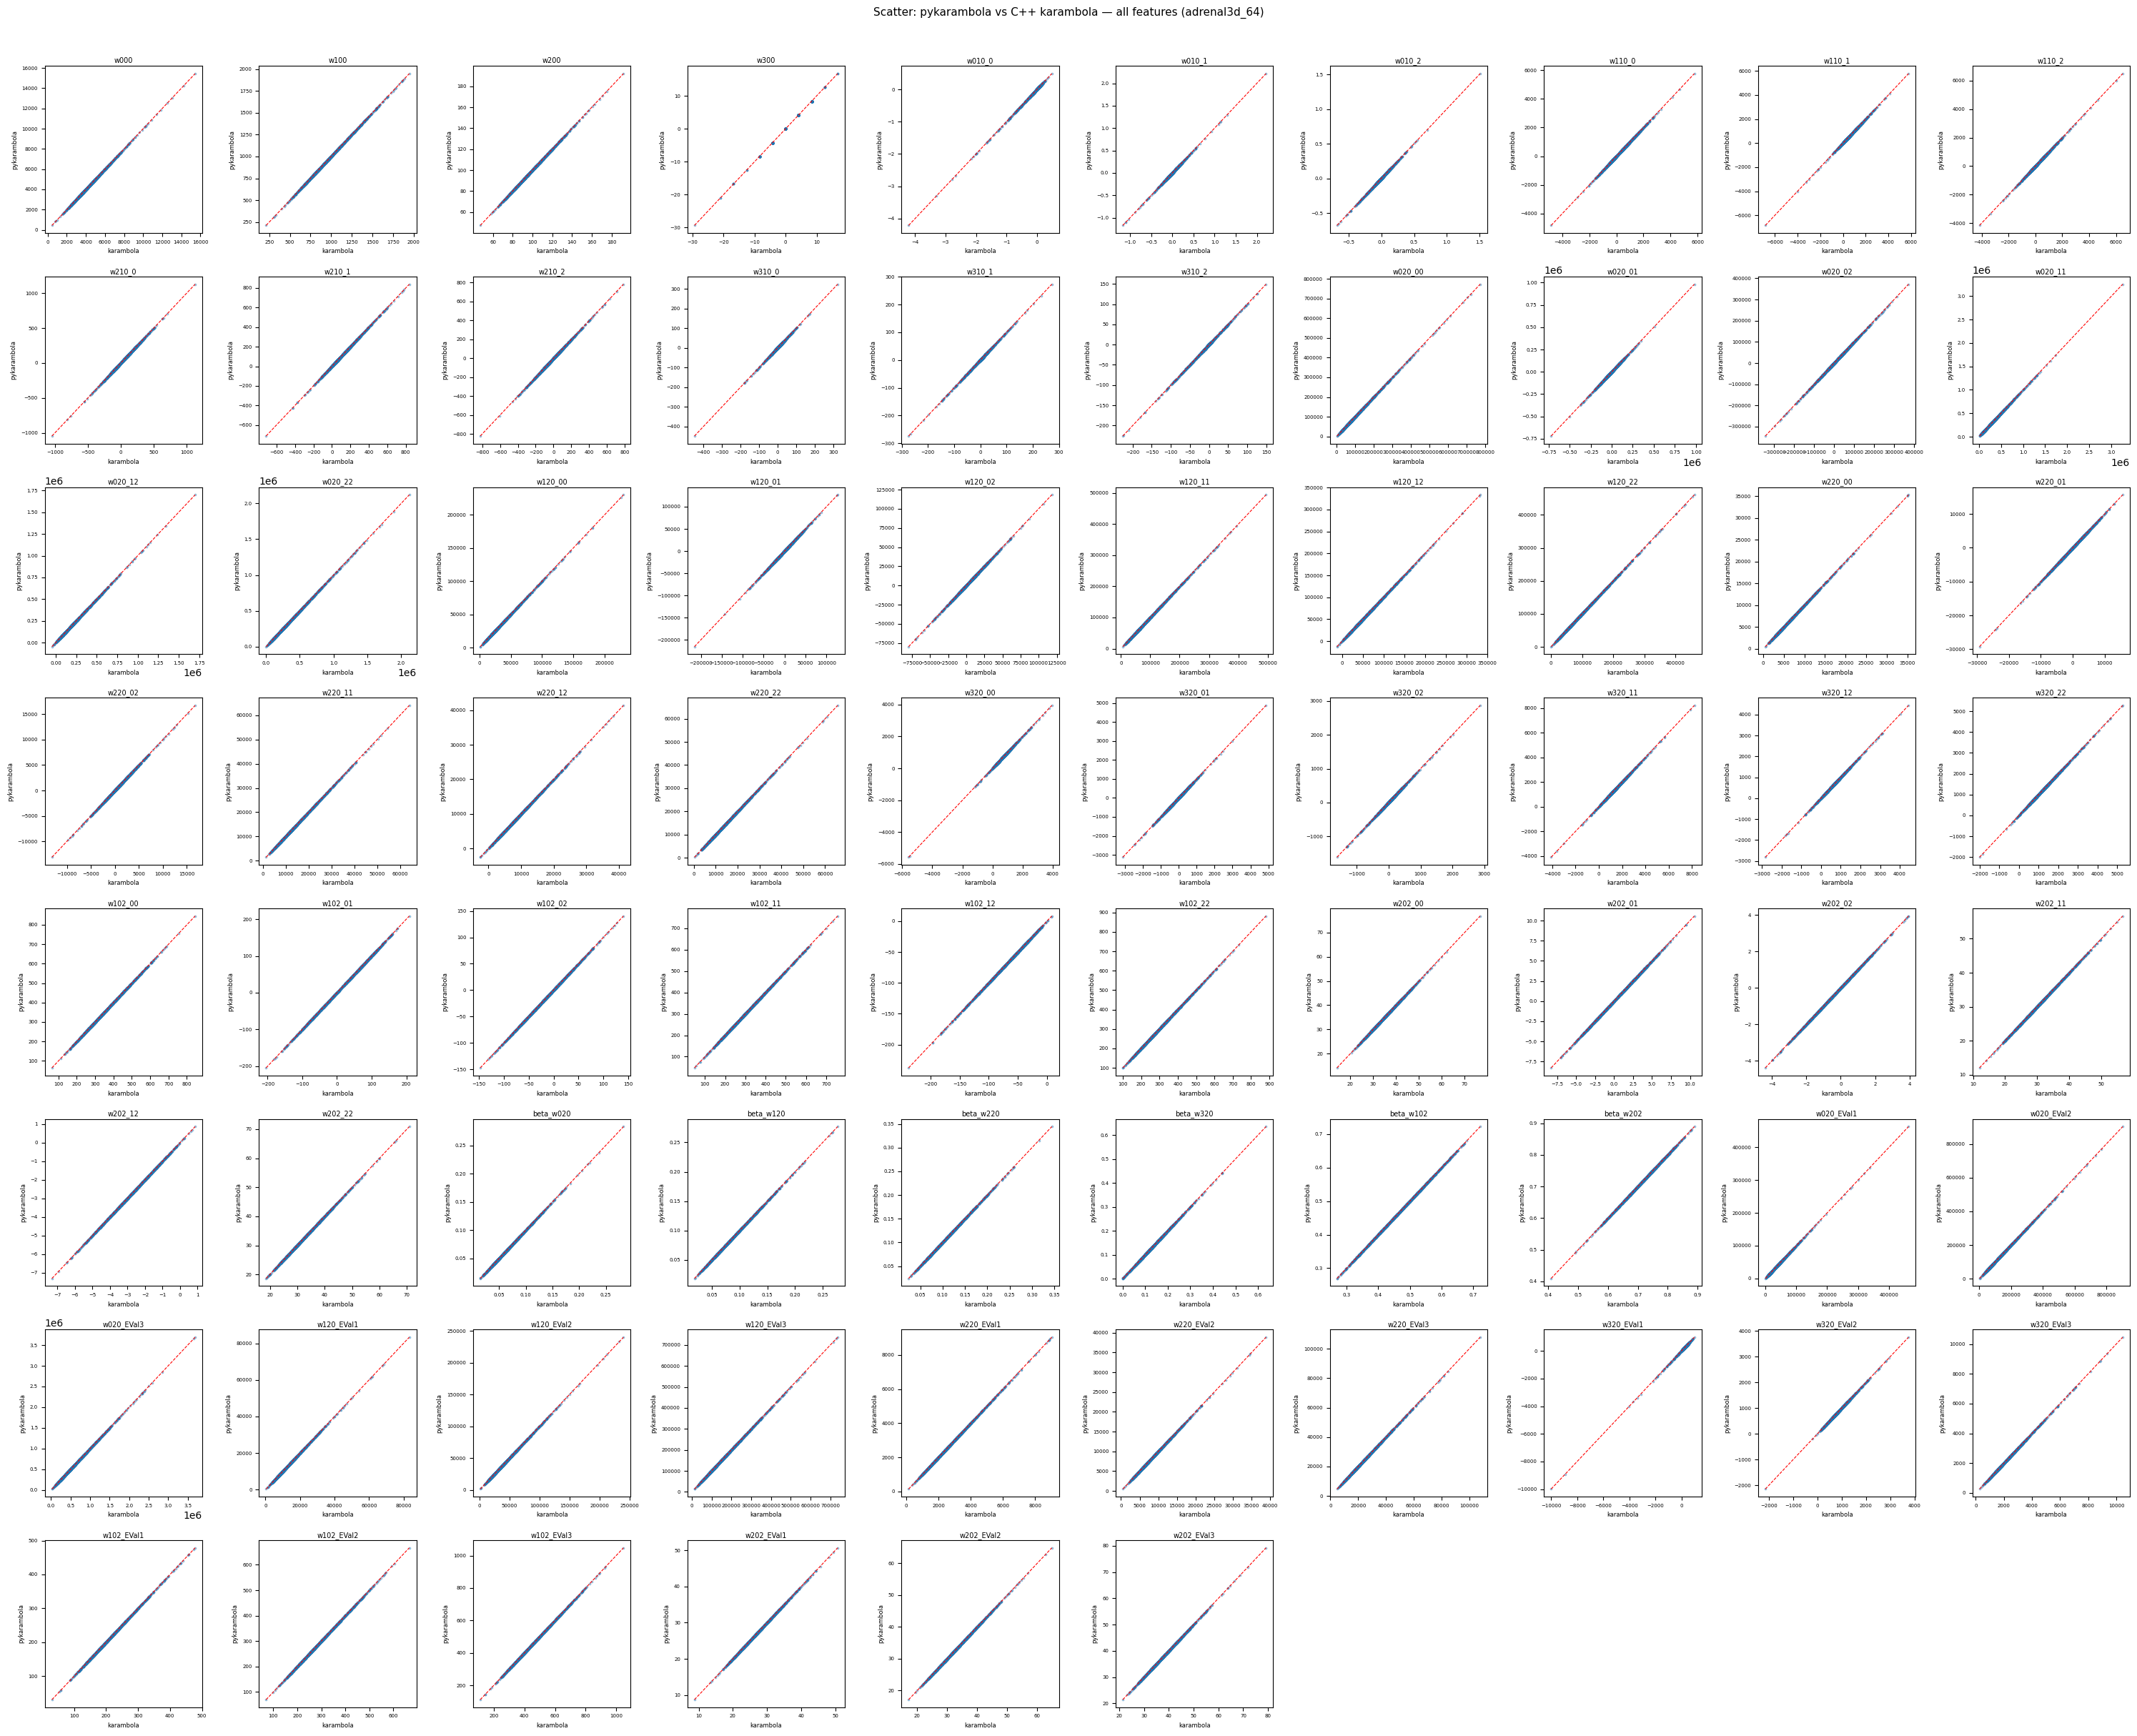

In [18]:
all_features = (
    SCALAR_KEYS
    + [f'{vk}_{i}' for vk in VECTOR_KEYS for i in range(3)]
    + [f'{tk}_{i}{j}' for tk in TENSOR_KEYS for i in range(3) for j in range(i, 3)]
    + [f'beta_{t}' for t in TENSOR_KEYS]
    + [f'{t}_EVal{n}' for t in TENSOR_KEYS for n in [1, 2, 3]]
)
# 4 scalars + 12 vector components + 36 tensor elements (upper triangle, symmetric)
# + 6 betas + 18 eigenvalues = 76 features total

NCOLS = 10
NROWS = 8   # 10 × 8 = 80 slots ≥ 76

for channel in CHANNELS:
    df_m = merged[channel]

    fig, axes = plt.subplots(NROWS, NCOLS, figsize=(NCOLS * 3, NROWS * 3))
    axes = axes.flatten()

    for idx, feat in enumerate(all_features):
        ax = axes[idx]
        k_vals  = df_m[f'{feat}_k']
        py_vals = df_m[f'{feat}_py']
        ax.scatter(k_vals, py_vals, s=3, alpha=0.35, rasterized=True)
        lo = min(k_vals.min(), py_vals.min())
        hi = max(k_vals.max(), py_vals.max())
        ax.plot([lo, hi], [lo, hi], 'r--', lw=0.8)
        ax.set_title(feat, fontsize=7, pad=3)
        ax.set_xlabel('karambola', fontsize=6)
        ax.set_ylabel('pykarambola', fontsize=6)
        ax.tick_params(labelsize=5)

    # Hide any unused axes
    for idx in range(len(all_features), len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle(f'Scatter: pykarambola vs C++ karambola — all features (adrenal3d_{channel})',
                 fontsize=11, y=1.01)
    plt.tight_layout()
    fig_path = os.path.join(FIGURES_PATH, f'scatter_all_features_{channel}.pdf')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f'Saved → {fig_path}')
    plt.show()

### Figure 2 — Bar chart: mean relative error per functional

Saved → results/bar_mean_relative_error.pdf


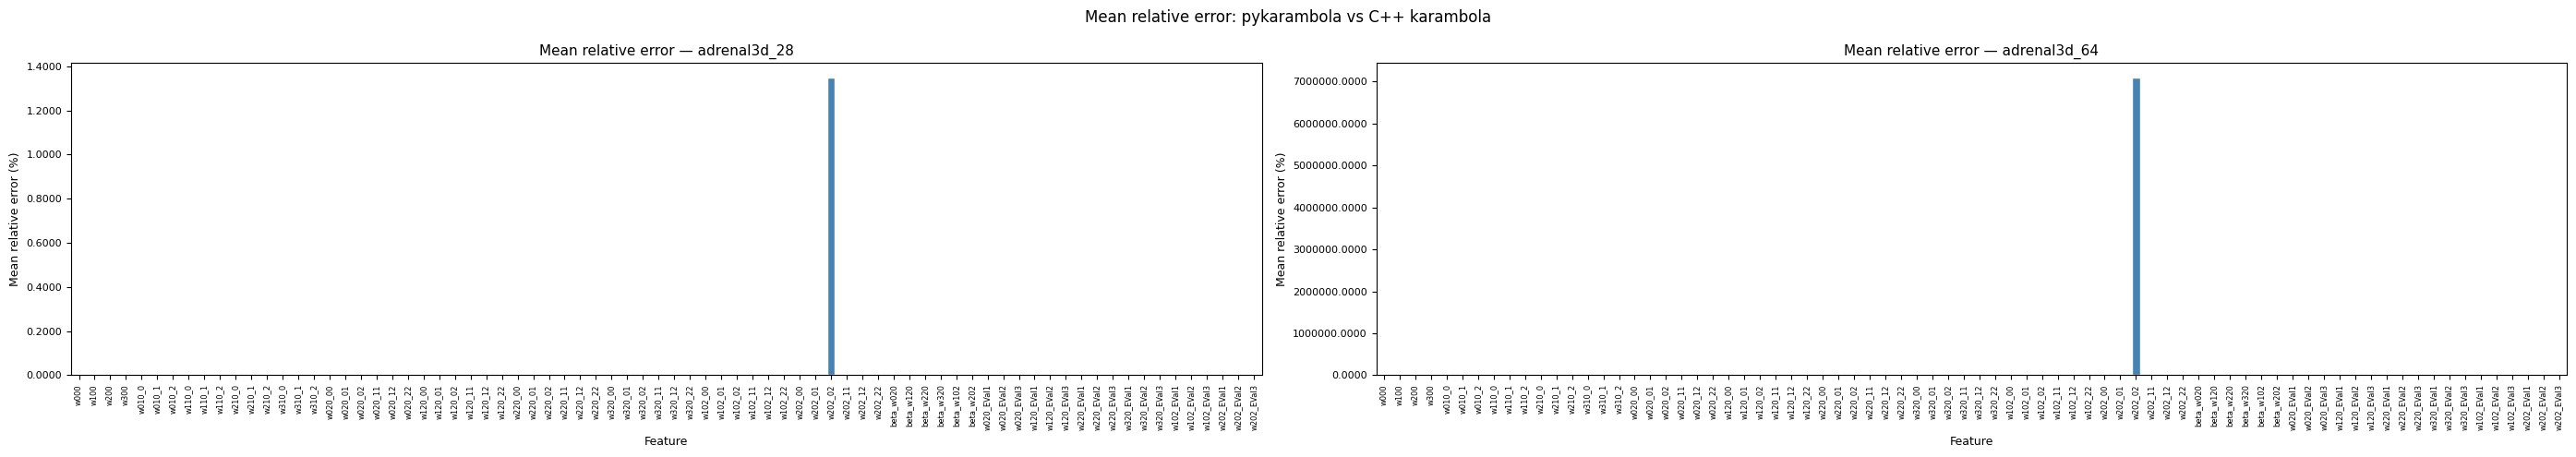

In [19]:
compare_cols = (
    SCALAR_KEYS
    + [f'{vk}_{i}' for vk in VECTOR_KEYS for i in range(3)]
    + [f'{tk}_{i}{j}' for tk in TENSOR_KEYS for i in range(3) for j in range(i, 3)]
    + [f'beta_{t}' for t in TENSOR_KEYS]
    + [f'{t}_EVal{n}' for t in TENSOR_KEYS for n in [1, 2, 3]]
)

fig, axes = plt.subplots(1, 2, figsize=(28, 5), sharey=False)

for ax, channel in zip(axes, CHANNELS):
    df_m = merged[channel]
    summary = error_summary(df_m, compare_cols)

    summary['mean_rel_err_%'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Mean relative error — adrenal3d_{channel}', fontsize=11)
    ax.set_xlabel('Feature', fontsize=9)
    ax.set_ylabel('Mean relative error (%)', fontsize=9)
    ax.tick_params(axis='x', rotation=90, labelsize=6)
    ax.tick_params(axis='y', labelsize=8)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))

plt.suptitle('Mean relative error: pykarambola vs C++ karambola', fontsize=12)
plt.tight_layout()
fig_path = os.path.join(FIGURES_PATH, 'bar_mean_relative_error.pdf')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'Saved → {fig_path}')
plt.show()

### Table — max and mean relative error per functional

In [20]:
for channel in CHANNELS:
    df_m = merged[channel]
    summary = error_summary(df_m, compare_cols)
    print(f'\n=== adrenal3d_{channel} ===')
    print(summary.to_string(float_format='{:.6f}'.format))
    csv_path = os.path.join(BASE_OUT_PATH, f'adrenal3d_{channel}',
                            'error_summary.csv')
    summary.to_csv(csv_path)
    print(f'Saved → {csv_path}')


=== adrenal3d_28 ===
            mean_rel_err_%  max_rel_err_%
feature                                  
w000              0.000000       0.000000
w100              0.000000       0.000000
w200              0.000001       0.000002
w300              0.000000       0.000000
w010_0            0.000000       0.000007
w010_1            0.000000       0.000031
w010_2            0.000000       0.000034
w110_0            0.000000       0.000000
w110_1            0.000000       0.000000
w110_2            0.000000       0.000000
w210_0            0.000003       0.000668
w210_1            0.000008       0.001876
w210_2            0.000014       0.003523
w310_0            0.000000       0.000000
w310_1            0.000000       0.000000
w310_2            0.000000       0.000000
w020_00           0.000000       0.000000
w020_01           0.000000       0.000000
w020_02           0.000000       0.000000
w020_11           0.000000       0.000000
w020_12           0.000000       0.000000
w020_22     

### Figure 3 — Heatmap: mean relative error per shape label × feature

Saved → results/heatmap_relative_error_28.pdf


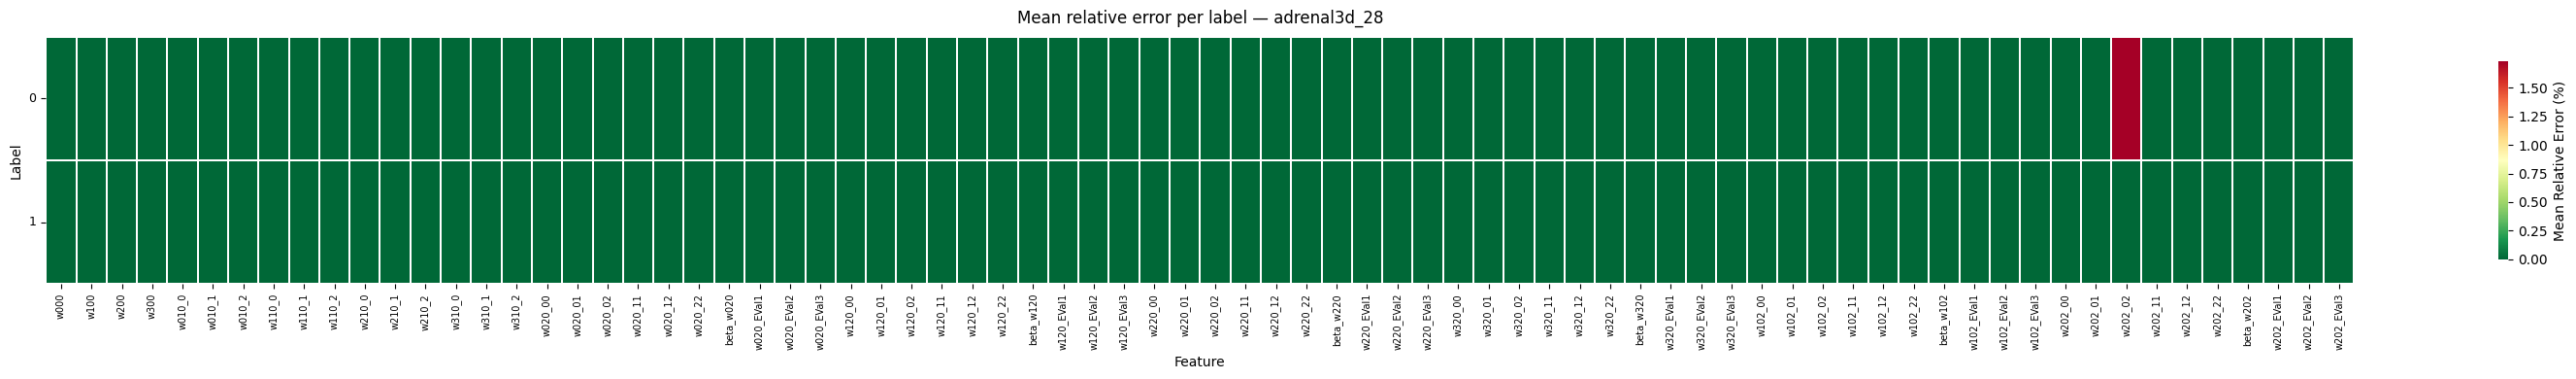

Saved → results/heatmap_relative_error_64.pdf


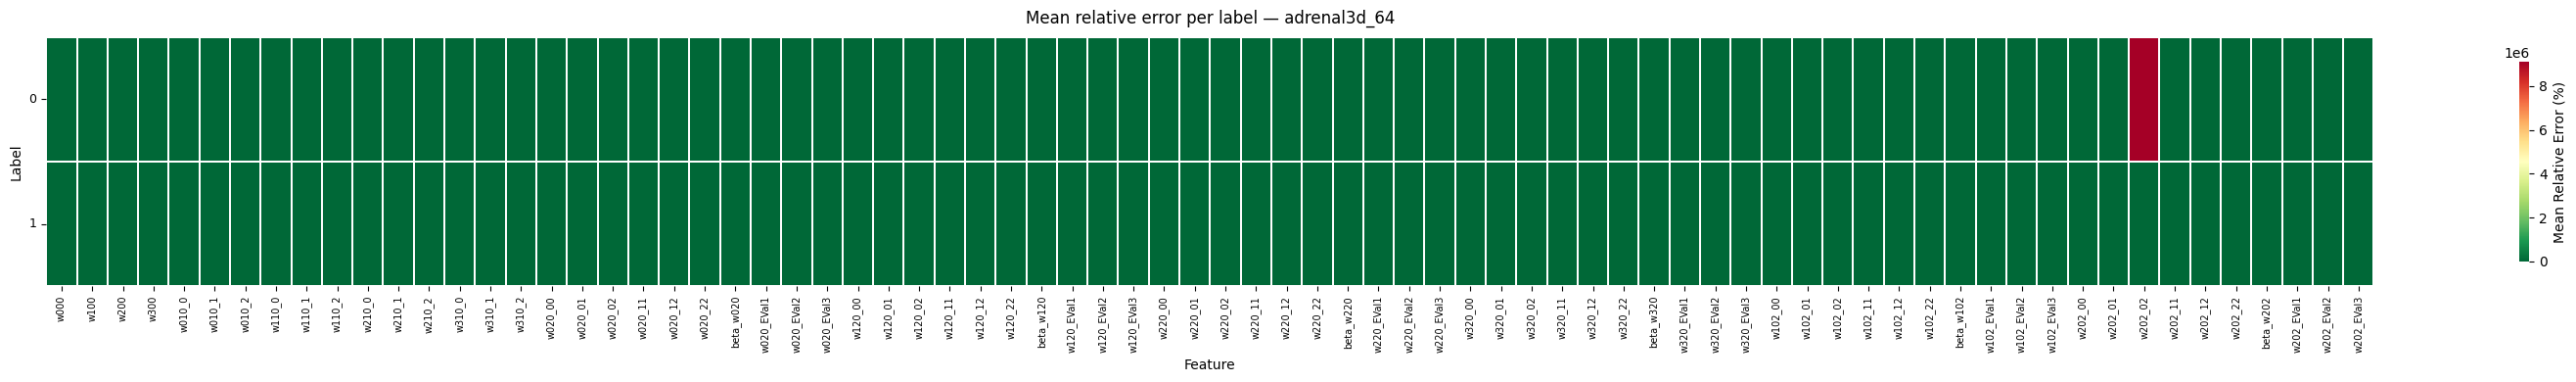

In [21]:
for channel in CHANNELS:
    df_m = merged[channel]
    numeric_cols = [c.replace('_k', '') for c in df_m.columns
                    if c.endswith('_k') and c.replace('_k', '') in compare_cols]

    heatmap_rows = []
    for lbl in sorted(df_m['label'].unique()):
        mask = df_m['label'] == lbl
        row = {'label': lbl}
        for col in numeric_cols:
            row[col] = relative_error_series(df_m[mask], col).mean()
        heatmap_rows.append(row)

    hmap_df = pd.DataFrame(heatmap_rows).set_index('label').fillna(0)

    fig, ax = plt.subplots(figsize=(max(14, len(hmap_df.columns) * 0.4), 4))
    seaborn.heatmap(
        hmap_df, annot=False, cmap='RdYlGn_r', linewidths=0.2, ax=ax,
        cbar_kws={'label': 'Mean Relative Error (%)', 'shrink': 0.8}
    )
    ax.set_title(f'Mean relative error per label — adrenal3d_{channel}',
                 fontsize=12, pad=10)
    ax.set_xlabel('Feature', fontsize=10)
    ax.set_ylabel('Label',   fontsize=10)
    ax.tick_params(axis='x', rotation=90, labelsize=7)
    ax.tick_params(axis='y', rotation=0,  labelsize=9)
    plt.tight_layout()
    fig_path = os.path.join(FIGURES_PATH, f'heatmap_relative_error_{channel}.pdf')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f'Saved → {fig_path}')
    plt.show()